# Warsaw EV - Analysis & Visuals
Using `dataset/sessions_enriched.csv` (sessions + station/customer/district context)

In [89]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

FIGS_DIR = "figs"
os.makedirs(FIGS_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS_DIR, name), dpi=150, bbox_inches="tight")

In [90]:
enriched_path = "../dataset/sessions_enriched.csv"

se = pd.read_csv(enriched_path, parse_dates=["session_start_time"])

print("Shape:", se.shape)

Shape: (114000, 23)


In [108]:
import folium
import pandas as pd
from branca.element import Element

# --- choose a stations-like dataframe to plot ---
# If you have the enriched df `se`, build a unique stations view from it (avoids duplicates).
if 'se' in globals():
    stations_map = (
        se[['station_id','latitude','longitude','operator_name','plugs_count','station_income_tier', 'district_name']]
        .dropna(subset=['latitude','longitude'])
        .drop_duplicates('station_id')
    )

# --- color mapping (normalize variants to Low/Mid/High) ---
tier_colors = {
    'low': 'blue',
    'mid': 'green',
    'high': 'red'
}

def normalize_tier(t):
    t = str(t).strip()
    return {
        'Low-Mid':'Low',
        'Mid-Range':'Mid',
        'Medium':'Mid',
        'LOW':'Low',
        'MID':'Mid',
        'HIGH':'High'
    }.get(t, t if t in ['Low','Mid','High'] else 'Unknown')

# --- build the map ---
warsaw_center = [52.2297, 21.0122]
m = folium.Map(location=warsaw_center, zoom_start=12)

for _, row in stations_map.iterrows():
    lat, lon = row['latitude'], row['longitude']
    if pd.isna(lat) or pd.isna(lon):
        continue

    tier = row.get('station_income_tier', 'Unknown')
    color = tier_colors.get(tier, 'gray')

    popup = (
        f"<b>Station:</b> {row.get('station_id','?')}<br>"
        f"<b>District:</b> {row.get('district_name', '?')}<br>"
        f"<b>Operator:</b> {row.get('operator_name','?')}<br>"
        f"<b>Income Tier:</b> {tier}"
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=popup
    ).add_to(m)

# --- legend that matches the colors above ---
legend_html = """
<div style="
    position: fixed; bottom: 40px; left: 40px; width: 160px;
    border: 2px solid #888; z-index: 9999; font-size: 14px;
    background: white; padding: 10px; border-radius: 8px;">
    <b>Income Tier</b><br>
    <div style="margin-top:6px;">
      <span style="display:inline-block;width:12px;height:12px;background:blue;margin-right:8px;border:1px solid #555;"></span> Low<br>
      <span style="display:inline-block;width:12px;height:12px;background:green;margin-right:8px;border:1px solid #555;"></span> Mid<br>
      <span style="display:inline-block;width:12px;height:12px;background:red;margin-right:8px;border:1px solid #555;"></span> High<br>
      <span style="display:inline-block;width:12px;height:12px;background:gray;margin-right:8px;border:1px solid #555;"></span> Unknown
    </div>
</div>
"""
m.get_root().html.add_child(Element(legend_html))

m

## Graphing


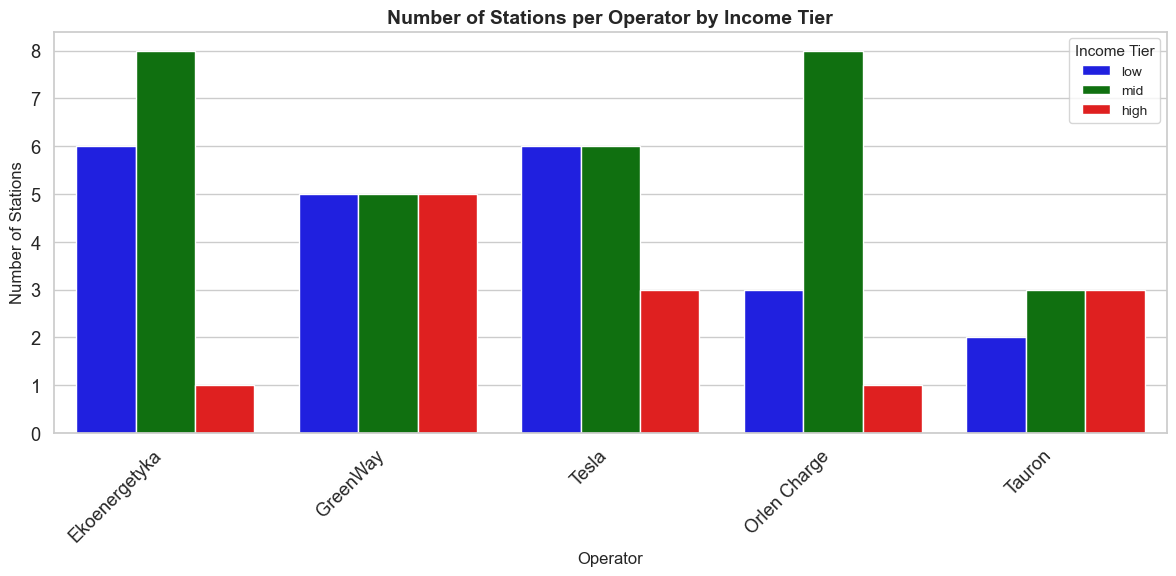


Summary:
station_income_tier  high  low  mid
operator_name                      
Ekoenergetyka           1    6    8
GreenWay                5    5    5
Orlen Charge            1    3    8
Tauron                  3    2    3
Tesla                   3    6    6


In [92]:
# Get unique stations per operator and income tier
stations_unique = (
    se[['station_id', 'operator_name', 'station_income_tier']]
    .dropna(subset=['operator_name', 'station_income_tier'])
    .drop_duplicates('station_id')
)

# Create countplot showing stations per operator by income tier
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(
    data=stations_unique,
    x='operator_name',
    hue='station_income_tier',
    order=stations_unique['operator_name'].value_counts().index,
    hue_order=['low', 'mid', 'high'],
    palette={'low': 'blue', 'mid': 'green', 'high': 'red'}
)
plt.title('Number of Stations per Operator by Income Tier', fontsize=14, fontweight='bold')
plt.xlabel('Operator', fontsize=12)
plt.ylabel('Number of Stations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income Tier', title_fontsize=11, fontsize=10)
savefig('stations_per_operator_by_income_tier.png')
plt.show()

# Print summary statistics
print("\nSummary:")
print(stations_unique.groupby(['operator_name', 'station_income_tier']).size().unstack(fill_value=0))

### Realized Price per kWh

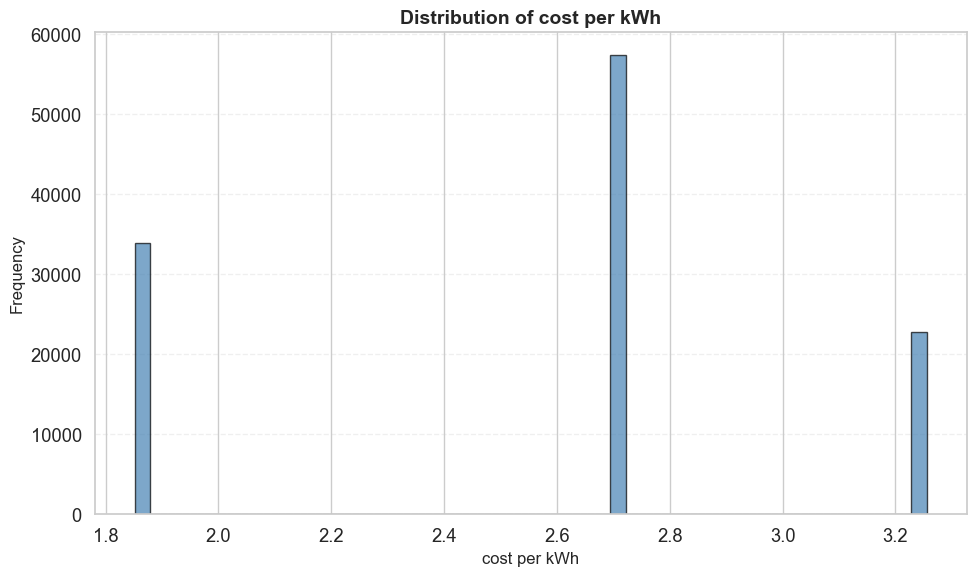

Summary Statistics:
count    114000.000000
mean          2.561615
std           0.506239
min           1.851397
25%           1.851397
50%           2.704520
75%           2.704520
max           3.256199
Name: cost_per_kwh, dtype: float64

Unique price values: [1.8513967524242176, 2.704520137017849, 3.256198927234891]


In [93]:
# Create histogram of cost per kWh
plt.figure(figsize=(10, 6))
plt.hist(se['cost_per_kwh'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribution of cost per kWh', fontsize=14, fontweight='bold')
plt.xlabel('cost per kWh', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
savefig('cost_per_kwh_histogram.png')
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(se['cost_per_kwh'].describe())
print(f"\nUnique price values: {sorted(se['cost_per_kwh'].dropna().unique())}")


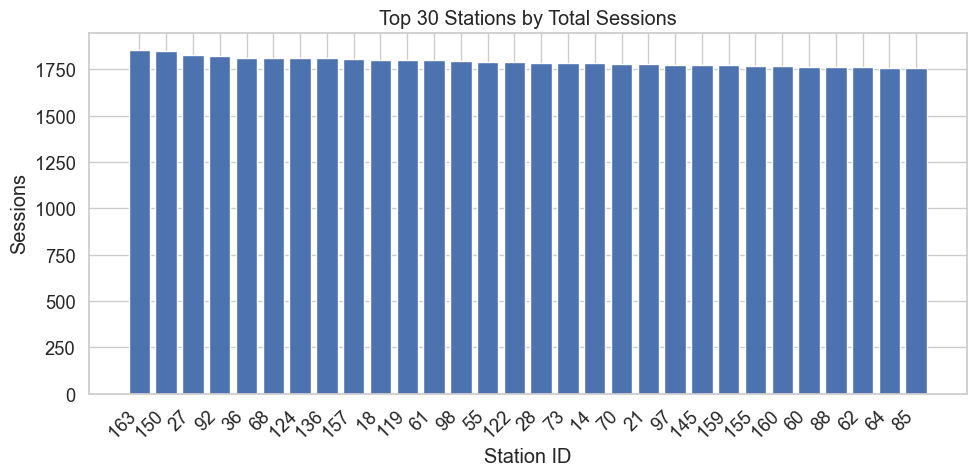

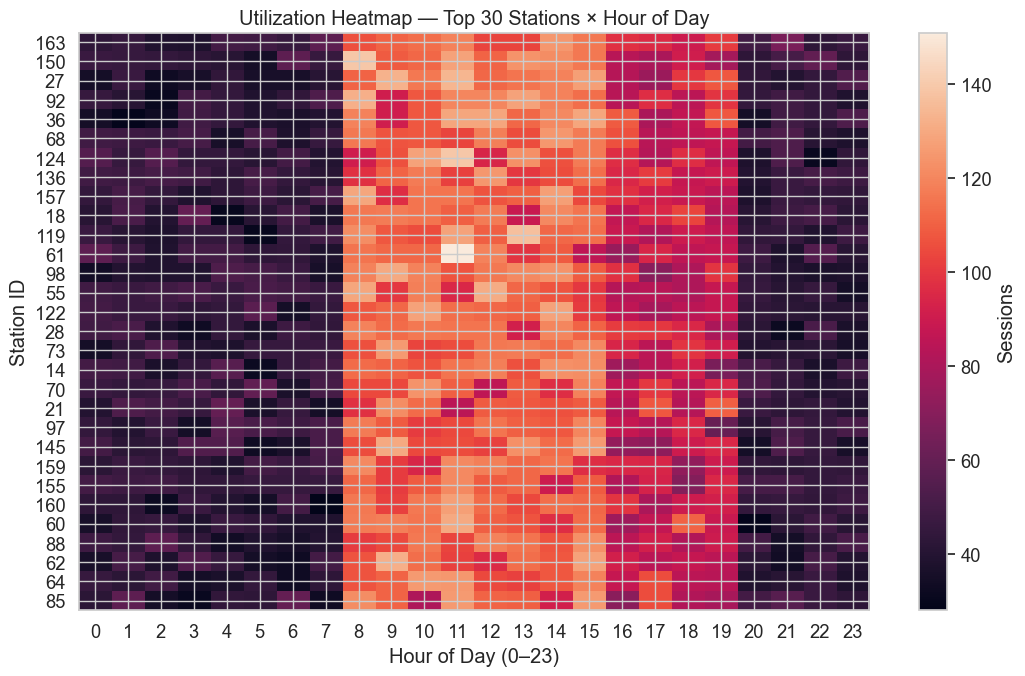

,station_id,peak_hour,peak_sessions
0,163,14,125
1,150,8,139
2,27,11,134
3,92,8,132
4,36,11,129
5,68,14,125
6,124,11,139
7,136,12,125
8,157,8,129
9,18,14,121


In [94]:
# 0) Load (uses existing `se` if present; otherwise reads from a common path)
if 'se' not in globals():
    se = pd.read_csv("../dataset/sessions_enriched.csv", parse_dates=["session_start_time"])

# 1) Ensure needed columns exist / are clean
se["hour"] = pd.to_numeric(se["hour"], errors="coerce").astype("Int64")
se = se.dropna(subset=["station_id", "hour"]).copy()
se["hour"] = se["hour"].astype(int)

# 2) Count sessions per station × hour
station_hour = (
    se.groupby(["station_id", "hour"])["session_id"]
      .count()
      .rename("sessions")
      .reset_index()
)

# 3) Find busiest stations overall
station_totals = (
    station_hour.groupby("station_id")["sessions"]
                .sum()
                .sort_values(ascending=False)
)

TOP_N = 30# tweak this if you want fewer/more
top_stations = station_totals.head(TOP_N).index.tolist()

# 4) FIGURE A — Top N stations by total sessions (bar)
plt.figure(figsize=(10,5))
vals = station_totals.loc[top_stations]
plt.bar([str(s) for s in top_stations], vals.values)
plt.title(f"Top {TOP_N} Stations by Total Sessions")
plt.xlabel("Station ID")
plt.ylabel("Sessions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5) FIGURE B — Heatmap: station × hour for Top N stations
mat = (
    station_hour[station_hour["station_id"].isin(top_stations)]
      .pivot(index="station_id", columns="hour", values="sessions")
      .fillna(0)
)

# make sure all hours 0..23 appear as columns in order
all_hours = list(range(24))
for h in all_hours:
    if h not in mat.columns:
        mat[h] = 0
mat = mat[all_hours]

# order rows by total usage (same order as bar chart)
mat = mat.loc[top_stations]

plt.figure(figsize=(11,7))
plt.imshow(mat.values, aspect="auto")
plt.title(f"Utilization Heatmap — Top {TOP_N} Stations × Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Station ID")
plt.xticks(ticks=np.arange(24), labels=all_hours)
plt.yticks(ticks=np.arange(len(mat.index)), labels=[str(s) for s in mat.index])
cbar = plt.colorbar()
cbar.set_label("Sessions")
plt.tight_layout()
plt.show()

# 6) Optional: table of each top station’s peak hour
peak_hour = mat.idxmax(axis=1)
peak_sessions = mat.max(axis=1)
peak_table = (
    pd.DataFrame({"station_id": mat.index, "peak_hour": peak_hour, "peak_sessions": peak_sessions})
      .reset_index(drop=True)
)
display(peak_table.head(10))

In [95]:
# plugs per district (sum unique station plugs)
plugs = (se[['station_id','district_name','plugs_count']]
         .drop_duplicates('station_id')
         .groupby('district_name')['plugs_count']
         .sum()
         .rename('plugs'))   # <- give it a column name

# projected EVs per district (take one value per district)
evs = (se[['district_name','projected_evs']]
       .drop_duplicates()
       .groupby('district_name')['projected_evs']
       .max())

evs_per_plug = (
    evs.to_frame()                      # 'projected_evs'
       .join(plugs, how='inner')        # adds 'plugs'
       .assign(evs_per_plug=lambda d: d['projected_evs'] / d['plugs'])
       .replace([np.inf, -np.inf], np.nan)
       .dropna(subset=['evs_per_plug'])
       .sort_values('evs_per_plug', ascending=False)
)
evs_per_plug.head(10)

cust = (se[['district_name','projected_regular_customers']]
        .drop_duplicates()
        .groupby('district_name')['projected_regular_customers']
        .max())

cust_per_plug = (
    cust.to_frame()
        .join(plugs, how='inner')       # uses the same 'plugs' Series
        .assign(users_per_plug=lambda d: d['projected_regular_customers'] / d['plugs'])
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=['users_per_plug'])
        .sort_values('users_per_plug', ascending=False)
)
cust_per_plug.head(10)

# sessions per district×hour
sess = se.groupby(['district_name','hour'])['session_id'].count().rename('sessions')

# align plugs to districts (reset/merge avoids MultiIndex join quirks)
spp = (sess.to_frame()
           .reset_index()
           .merge(plugs.to_frame(), on='district_name', how='left')  # adds 'plugs'
           .assign(sessions_per_plug=lambda d: d['sessions'] / d['plugs'].replace({0: np.nan}))
      )
spp.head()

,district_name,hour,sessions,plugs,sessions_per_plug
0,Bemowo,0,86,12,7.166667
1,Bemowo,1,99,12,8.250000
2,Bemowo,2,87,12,7.250000
3,Bemowo,3,98,12,8.166667
4,Bemowo,4,90,12,7.500000


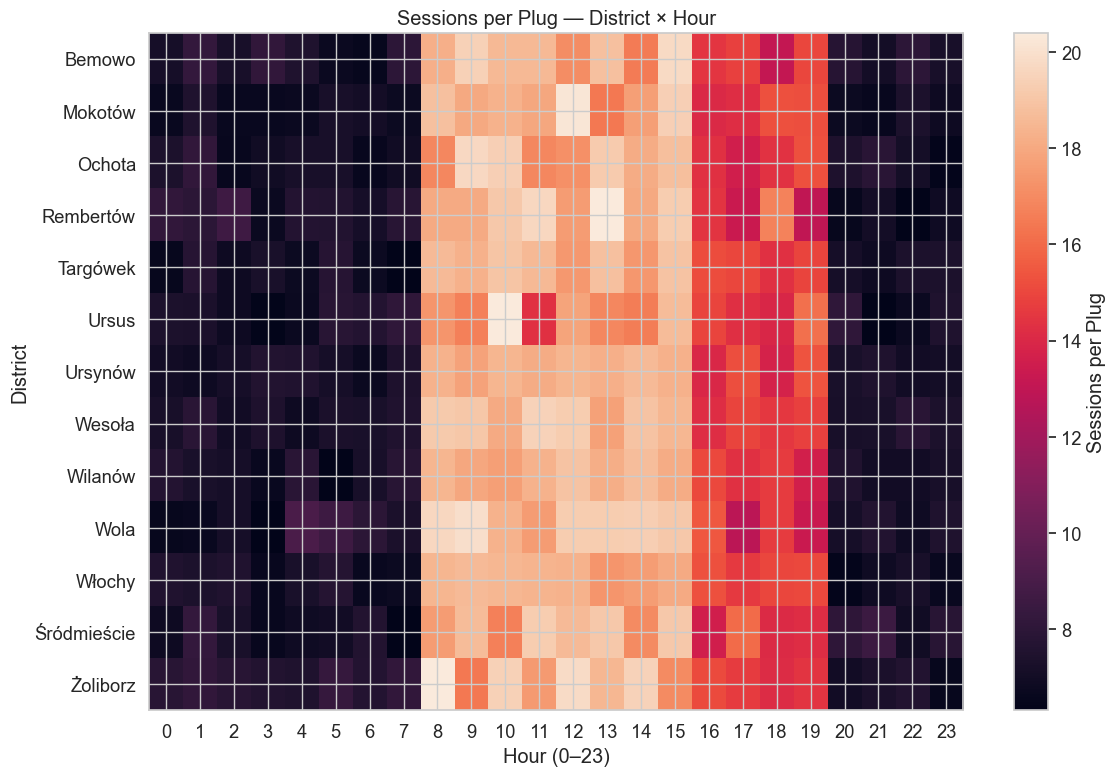

In [96]:
import numpy as np
import matplotlib.pyplot as plt

mat = (spp.pivot(index="district_name", columns="hour", values="sessions_per_plug")
          .fillna(0.0))

# optional: clip color scale to reduce outlier washout
vmin = mat.quantile(0.05).min()
vmax = mat.quantile(0.95).max()

plt.figure(figsize=(12,8))
plt.imshow(mat.values, aspect="auto", vmin=vmin, vmax=vmax)
plt.title("Sessions per Plug — District × Hour")
plt.xlabel("Hour (0–23)")
plt.ylabel("District")
plt.xticks(ticks=np.arange(24), labels=list(range(24)))
plt.yticks(ticks=np.arange(len(mat.index)), labels=mat.index.tolist())
cbar = plt.colorbar()
cbar.set_label("Sessions per Plug")
plt.tight_layout()
plt.show()

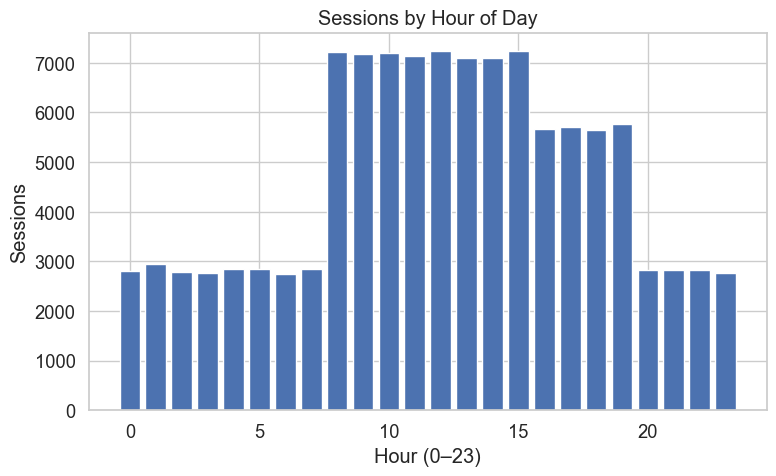

In [97]:
by_hour = (se.groupby("hour")["session_id"].count()
             .reindex(range(24), fill_value=0))

plt.figure(figsize=(8,5))
plt.bar(by_hour.index, by_hour.values)
plt.title("Sessions by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Sessions")
plt.tight_layout()
plt.savefig("figs/sessions_by_hour.png", dpi=150)
plt.show()

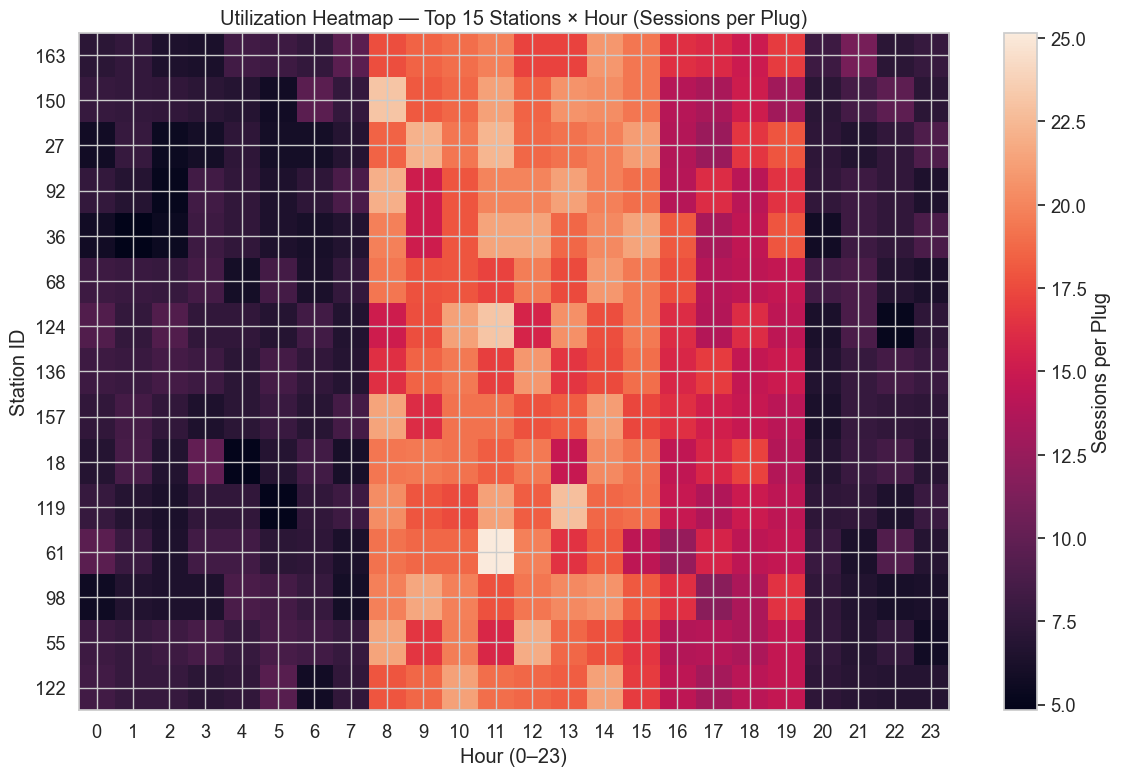

In [98]:
TOP_N = 15  # change to 10/20 if you want

# counts per station×hour
sh = (se.dropna(subset=["station_id","hour","plugs_count"])
        .assign(hour=lambda d: d["hour"].astype(int))
        .groupby(["station_id","hour"])["session_id"]
        .count()
        .rename("sessions")
        .reset_index())

# plugs per station (unique)
plugs_per_station = (se[["station_id","plugs_count"]]
                     .drop_duplicates("station_id")
                     .set_index("station_id")["plugs_count"])

sh["plugs_count"] = sh["station_id"].map(plugs_per_station)
sh["sessions_per_plug"] = sh["sessions"] / sh["plugs_count"].replace({0: np.nan})

# pick top stations by total sessions
top_stations = (sh.groupby("station_id")["sessions"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(TOP_N)
                  .index)

mat = (sh[sh["station_id"].isin(top_stations)]
       .pivot(index="station_id", columns="hour", values="sessions_per_plug")
       .fillna(0.0))

# ensure all 0..23 hours present and in order
all_hours = list(range(24))
for h in all_hours:
    if h not in mat.columns: mat[h] = 0.0
mat = mat[all_hours]

# order rows by total sessions
order = (sh.groupby("station_id")["sessions"].sum().loc[top_stations].index)
mat = mat.loc[order]

plt.figure(figsize=(12,8))
plt.imshow(mat.values, aspect="auto")
plt.title(f"Utilization Heatmap — Top {len(top_stations)} Stations × Hour (Sessions per Plug)")
plt.xlabel("Hour (0–23)")
plt.ylabel("Station ID")
plt.xticks(ticks=np.arange(24), labels=all_hours)
plt.yticks(ticks=np.arange(len(mat.index)), labels=[str(s) for s in mat.index])
cbar = plt.colorbar()
cbar.set_label("Sessions per Plug")
plt.tight_layout()
plt.savefig("figs/utilization_spp_heatmap_topN.png", dpi=150)
plt.show()

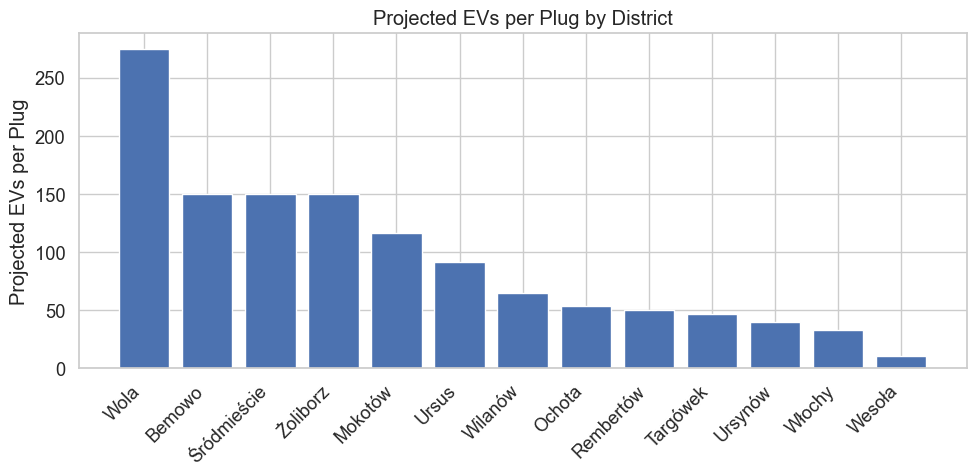

In [99]:
# sum unique station plugs in each district
plugs_by_district = (se[['station_id','district_name','plugs_count']]
                     .drop_duplicates('station_id')
                     .groupby('district_name')['plugs_count']
                     .sum()
                     .rename('plugs'))

# projected EVs (one value per district)
evs = (se[['district_name','projected_evs']]
       .drop_duplicates()
       .groupby('district_name')['projected_evs']
       .max())

evs_per_plug = (evs.to_frame()
                  .join(plugs_by_district, how='inner')
                  .assign(evs_per_plug=lambda d: d['projected_evs']/d['plugs'])
                  .replace([np.inf, -np.inf], np.nan)
                  .dropna(subset=['evs_per_plug'])
                  .sort_values('evs_per_plug', ascending=False))

plt.figure(figsize=(10,5))
plt.bar(evs_per_plug.index, evs_per_plug["evs_per_plug"].values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Projected EVs per Plug")
plt.title("Projected EVs per Plug by District")
plt.tight_layout()
plt.savefig("figs/evs_per_plug_by_district.png", dpi=150)
plt.show()

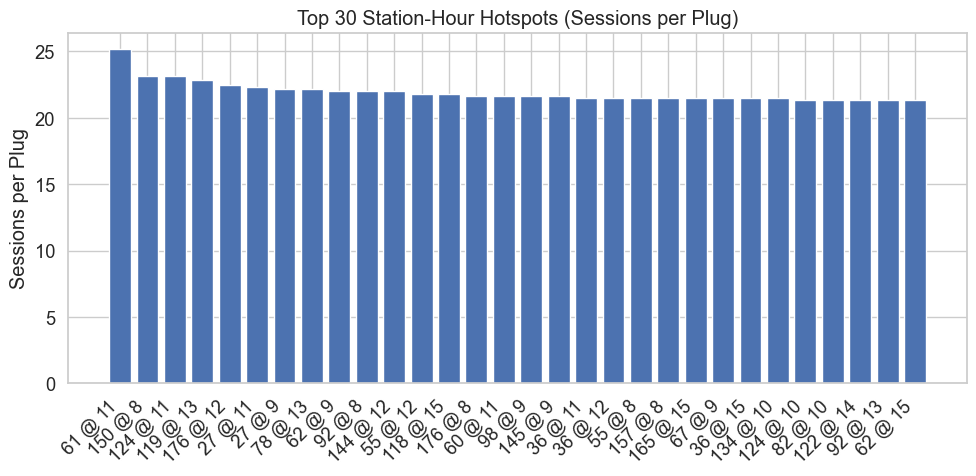

In [100]:
# reuse sh (station×hour) from Figure 2 if it's still in memory; otherwise rebuild quickly:
if 'sh' not in globals():
    sh = (se.dropna(subset=["station_id","hour","plugs_count"])
            .assign(hour=lambda d: d["hour"].astype(int))
            .groupby(["station_id","hour"])["session_id"].count().rename("sessions").reset_index())
    plugs_per_station = (se[["station_id","plugs_count"]]
                         .drop_duplicates("station_id")
                         .set_index("station_id")["plugs_count"])
    sh["plugs_count"] = sh["station_id"].map(plugs_per_station)
    sh["sessions_per_plug"] = sh["sessions"] / sh["plugs_count"].replace({0: np.nan})

# take top K station-hours by sessions-per-plug
K = 30
hotspots = sh.sort_values("sessions_per_plug", ascending=False).head(K).copy()
hotspots["label"] = hotspots["station_id"].astype(str) + " @ " + hotspots["hour"].astype(str)

# save table for the doc
hotspots_out = hotspots[["station_id","hour","sessions","plugs_count","sessions_per_plug"]]
hotspots_out.to_csv("figs/top_station_hour_hotspots.csv", index=False)

# bar chart for the poster (optional but nice)
plt.figure(figsize=(10,5))
plt.bar(hotspots["label"], hotspots["sessions_per_plug"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Sessions per Plug")
plt.title(f"Top {K} Station-Hour Hotspots (Sessions per Plug)")
plt.tight_layout()
plt.savefig("figs/top_station_hour_hotspots.png", dpi=150)
plt.show()

Using price column: cost_per_kwh | tier column: customer_income_tier


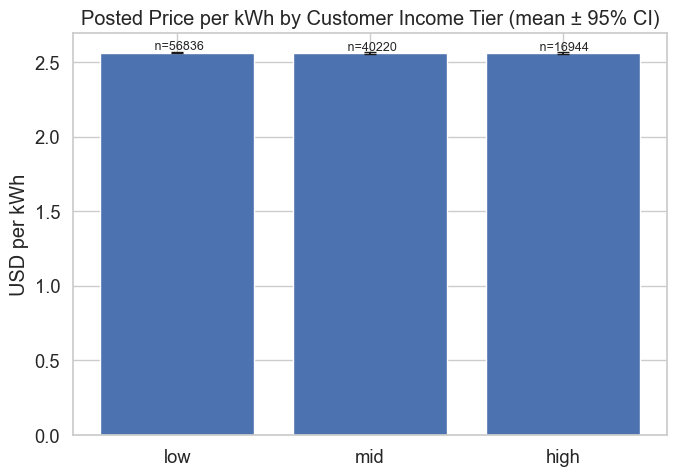

/var/folders/d0/7bjghg617tl5sp3h5hk8wtxm0000gn/T/ipykernel_13106/1783348785.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_tier, labels=order, showfliers=False)


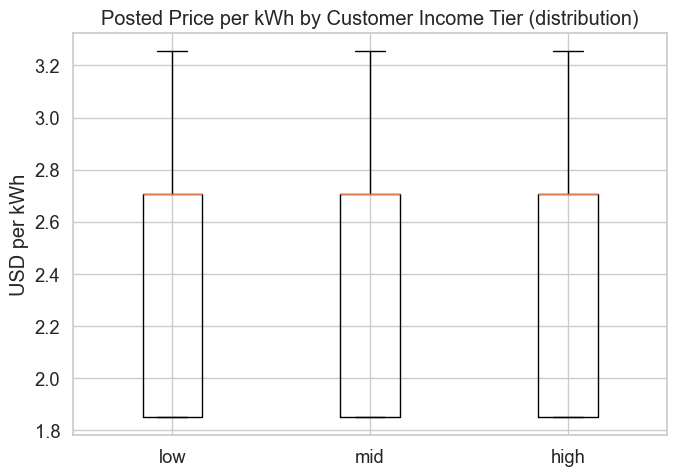

,mean_price,count
customer_income_tier,,
low,2.562510,56836
mid,2.560458,40220
high,2.561361,16944


In [101]:

# 1) choose price column (posted preferred)
PRICE_COL = "cost_per_kwh" if "cost_per_kwh" in se.columns else "price_per_kwh_realized"

# 2) choose tier column (customer → station → district)
for _c in ["customer_income_tier", "station_income_tier", "district_income_tier"]:
    if _c in se.columns:
        TIER_COL = _c
        break
else:
    raise ValueError("No income tier column found.")

print(f"Using price column: {PRICE_COL} | tier column: {TIER_COL}")

# 3) clean + normalize tiers to low/mid/high
def _norm_tier(x):
    if pd.isna(x): return np.nan
    t = str(x).strip().lower().replace("_","-").replace(" ","-")
    if t in {"low","mid","high"}: return t
    return {"low-mid":"mid","mid-range":"mid","medium":"mid"}.get(t, np.nan)

df = se[[TIER_COL, PRICE_COL]].copy()
df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")
df[TIER_COL] = df[TIER_COL].apply(_norm_tier)

df = df.dropna(subset=[TIER_COL, PRICE_COL])
df = df[df[TIER_COL].isin(["low","mid","high"])]

order = ["low","mid","high"]

# 4) aggregate stats for bar w/ 95% CI
g = (df.groupby(TIER_COL)[PRICE_COL]
       .agg(['mean','std','count'])
       .reindex(order))
g['se'] = g['std'] / np.sqrt(g['count']).replace(0, np.nan)
g['ci95'] = 1.96 * g['se']

# 5) BAR: mean ± 95% CI
os.makedirs("figs", exist_ok=True)

plt.figure(figsize=(7,5))
x = np.arange(len(order))
plt.bar(x, g['mean'], yerr=g['ci95'], capsize=4)
plt.xticks(x, order)
plt.ylabel("USD per kWh")
plt.title(f"Posted Price per kWh by {TIER_COL.replace('_',' ').title()} (mean ± 95% CI)")
# annotate counts
for i, (m, n) in enumerate(zip(g['mean'], g['count'])):
    plt.text(i, m, f" n={int(n)}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("figs/price_by_tier_bar.png", dpi=150)
plt.show()

# 6) BOX: distribution by tier
plt.figure(figsize=(7,5))
data_by_tier = [df.loc[df[TIER_COL]==t, PRICE_COL] for t in order]
plt.boxplot(data_by_tier, labels=order, showfliers=False)
plt.ylabel("USD per kWh")
plt.title(f"Posted Price per kWh by {TIER_COL.replace('_',' ').title()} (distribution)")
plt.tight_layout()
plt.savefig("figs/price_by_tier_box.png", dpi=150)
plt.show()

# quick text readout
display(g[['mean','count']].rename(columns={'mean':'mean_price'}))

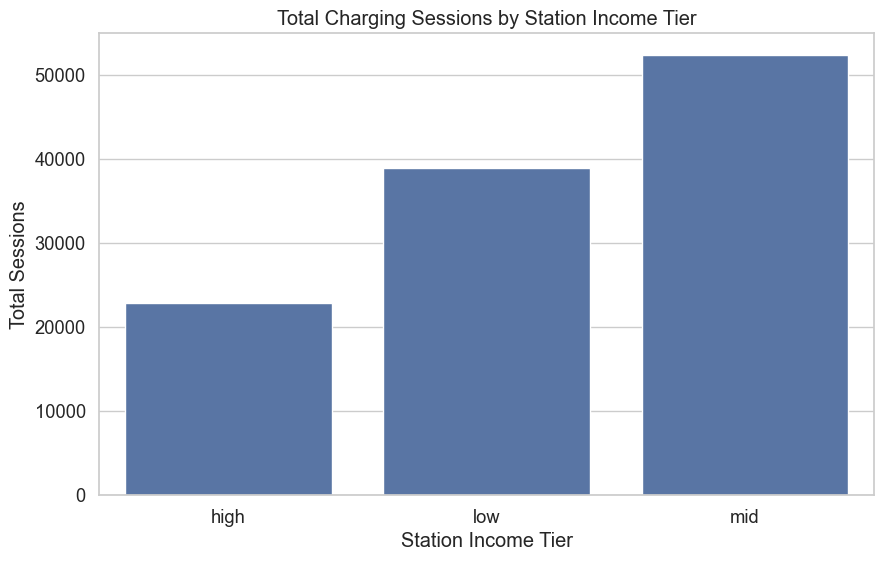

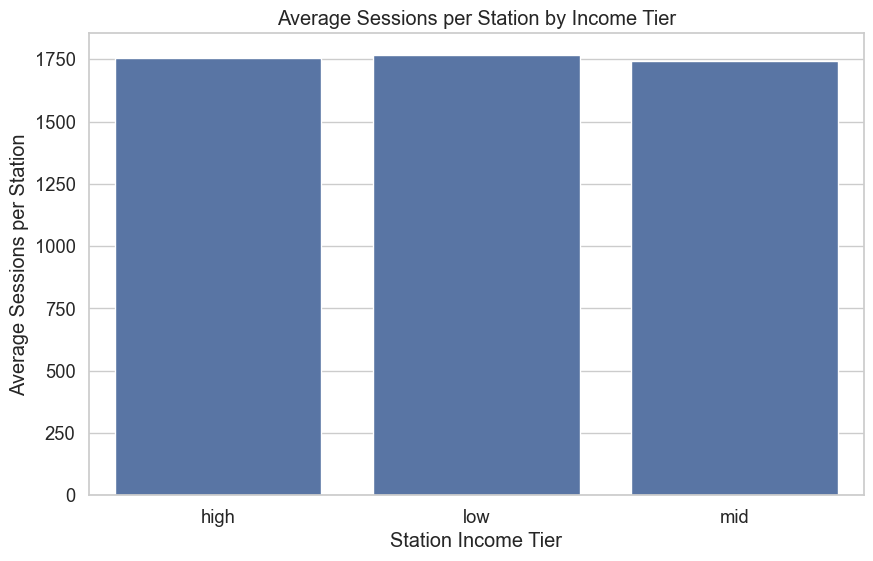

In [102]:
# Count sessions per station
station_usage = se.groupby('station_id').size().reset_index(name='session_count')

# Get income tier for each station (remove duplicates)
station_income = se[['station_id', 'station_income_tier']].drop_duplicates()

# Merge usage data with income tiers
station_data = station_usage.merge(station_income, on='station_id')

# Calculate total sessions per income tier
tier_totals = station_data.groupby('station_income_tier')['session_count'].sum().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=tier_totals, x='station_income_tier', y='session_count')
plt.title('Total Charging Sessions by Station Income Tier')
plt.xlabel('Station Income Tier')
plt.ylabel('Total Sessions')
plt.show()

# Also create a plot showing average sessions per station
tier_averages = station_data.groupby('station_income_tier')['session_count'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=tier_averages, x='station_income_tier', y='session_count')
plt.title('Average Sessions per Station by Income Tier')
plt.xlabel('Station Income Tier')
plt.ylabel('Average Sessions per Station')
plt.show()

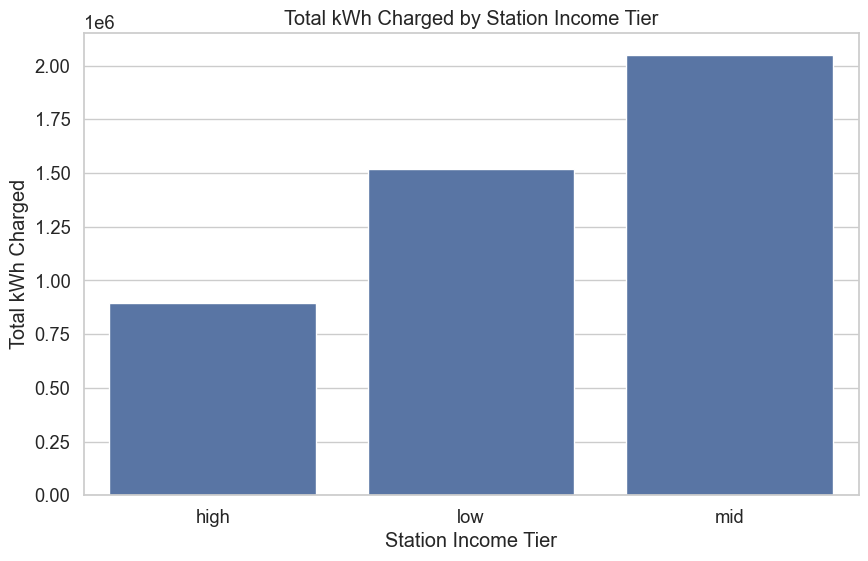

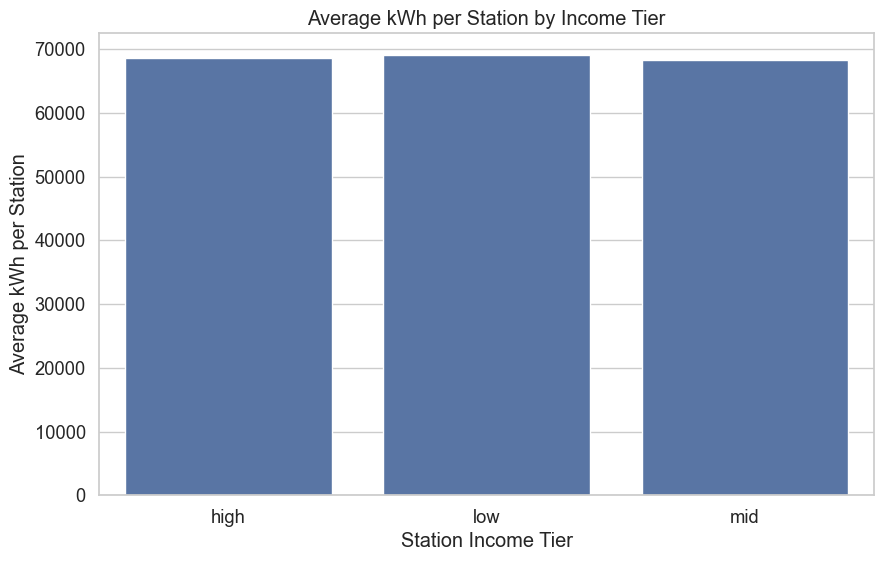

In [103]:
# Calculate total kWh charged per station
station_kwh = se.groupby('station_id')['kwh_charged'].sum().reset_index(name='total_kwh')

# Get income tier for each station (remove duplicates)
station_income = se[['station_id', 'station_income_tier']].drop_duplicates()

# Merge kWh data with income tiers
station_kwh_data = station_kwh.merge(station_income, on='station_id')

# Calculate total kWh per income tier
tier_kwh_totals = station_kwh_data.groupby('station_income_tier')['total_kwh'].sum().reset_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=tier_kwh_totals, x='station_income_tier', y='total_kwh')
plt.title('Total kWh Charged by Station Income Tier')
plt.xlabel('Station Income Tier')
plt.ylabel('Total kWh Charged')
plt.show()

# Also create a plot showing average kWh per station within each tier
tier_kwh_averages = station_kwh_data.groupby('station_income_tier')['total_kwh'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=tier_kwh_averages, x='station_income_tier', y='total_kwh')
plt.title('Average kWh per Station by Income Tier')
plt.xlabel('Station Income Tier')
plt.ylabel('Average kWh per Station')
plt.show()

## Notes:
- cost per kwh is the same for all income tiers. can talk about how it can be variable to maximize profits
- Wola, Bemowo, etc., have a lot of EVs per plug. should implement more 
- some districts experience large usage during peak hours compared to others. could also implement variable price based on time of day

## Seaborn plots

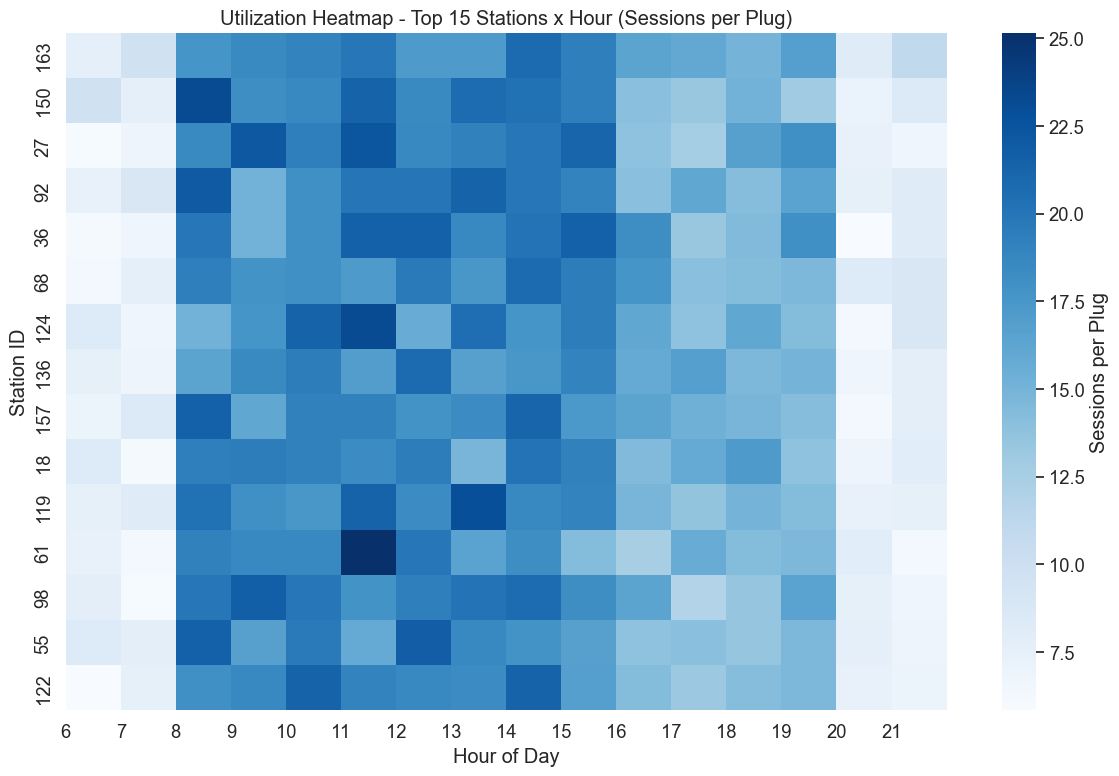

In [104]:
TOP_N = 15 

# counts per station×hour
sh = (se.dropna(subset=["station_id","hour","plugs_count"])
        .assign(hour=lambda d: d["hour"].astype(int))
        .groupby(["station_id","hour"])["session_id"]
        .count()
        .rename("sessions")
        .reset_index())

# plugs per station (unique)
plugs_per_station = (se[["station_id","plugs_count"]]
                     .drop_duplicates("station_id")
                     .set_index("station_id")["plugs_count"])

sh["plugs_count"] = sh["station_id"].map(plugs_per_station)
sh["sessions_per_plug"] = sh["sessions"] / sh["plugs_count"].replace({0: np.nan})

# pick top stations by total sessions
top_stations = (sh.groupby("station_id")["sessions"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(TOP_N)
                  .index)

mat = (sh[sh["station_id"].isin(top_stations)]
       .pivot(index="station_id", columns="hour", values="sessions_per_plug")
       .fillna(0.0))

# ensure all 0..23 hours present and in order
all_hours = list(range(6, 22))
for h in all_hours:
    if h not in mat.columns: mat[h] = 0.0
mat = mat[all_hours]

# order rows by total sessions
order = (sh.groupby("station_id")["sessions"].sum().loc[top_stations].index)
mat = mat.loc[order]

plt.figure(figsize=(12,8))
sns.heatmap(mat.values,
            cmap='Blues',
            annot = False,
            cbar_kws={'label': 'Sessions per Plug'})
plt.title(f"Utilization Heatmap - Top {len(top_stations)} Stations x Hour (Sessions per Plug)")
plt.yticks(ticks=np.arange(len(mat.index)) + .5, labels=[str(s) for s in mat.index], va='center')
plt.xticks(ticks=np.arange(len(all_hours)), labels=all_hours)
plt.xlabel("Hour of Day")
plt.ylabel("Station ID")
plt.tight_layout()
plt.savefig("figs/utilization_spp_heatmap_topN.png", dpi=150, bbox_inches='tight')

/var/folders/d0/7bjghg617tl5sp3h5hk8wtxm0000gn/T/ipykernel_13106/3094568861.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = evs_per_plug_plot,


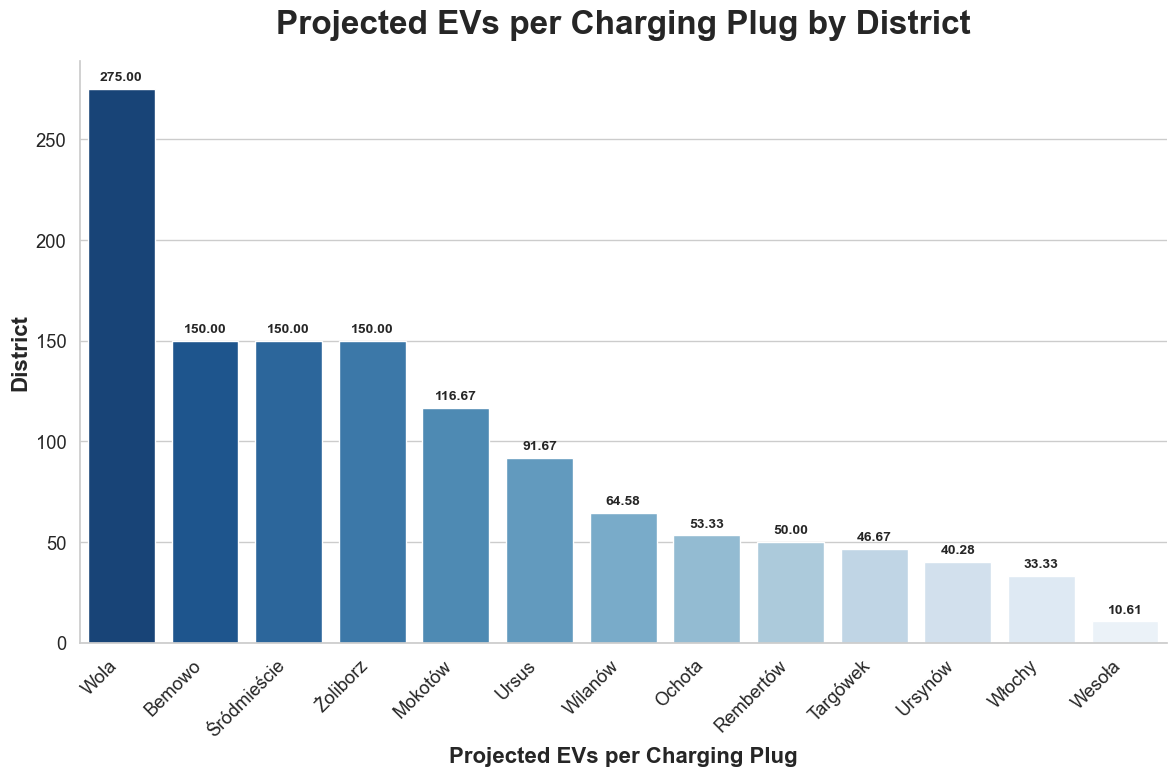

In [105]:
plugs_by_district = (se[['station_id', 'district_name', 'plugs_count']]
                     .drop_duplicates('station_id')
                     .groupby('district_name')['plugs_count']
                     .sum()
                     .rename('plugs'))

evs = (se[['district_name', 'projected_evs']]
       .drop_duplicates()
       .groupby('district_name')['projected_evs']
       .max())

evs_per_plug = (evs.to_frame()
                .join(plugs_by_district, how='inner')
                .assign(evs_per_plug=lambda d: d['projected_evs'] / d['plugs'])
                .replace([np.inf, -np.inf], np.nan)
                .dropna(subset=['evs_per_plug'])
                .sort_values('evs_per_plug', ascending=False))


evs_per_plug_plot = evs_per_plug.reset_index()
evs_per_plug_plot = evs_per_plug_plot.sort_values('evs_per_plug', ascending=False)

colors = sns.color_palette("Blues_r", n_colors=len(evs_per_plug_plot))

plt.figure(figsize=(12, 8))
plt.xticks(rotation=45, ha='right')
sns.set_style("whitegrid")
#sns.set(font_scale=1.2)
ax = sns.barplot(data = evs_per_plug_plot,
                 x='district_name',
                 y='evs_per_plug',
                 palette=colors,
                 orient='v')

for i, v in enumerate(evs_per_plug_plot['evs_per_plug']):
    ax.text(i, v + max(evs_per_plug_plot['evs_per_plug'])*0.01,
            f'{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
plt.xlabel('Projected EVs per Charging Plug', fontsize=16, fontweight='bold')
plt.ylabel('District', fontsize=16, fontweight='bold')
plt.title('Projected EVs per Charging Plug by District', 
          fontsize=24, fontweight='bold', pad=20)

sns.despine()  # Remove top and right borders
plt.tight_layout()

plt.savefig('figs/evs_per_plug_by_district_poster.png', dpi=300, bbox_inches='tight')
plt.show()

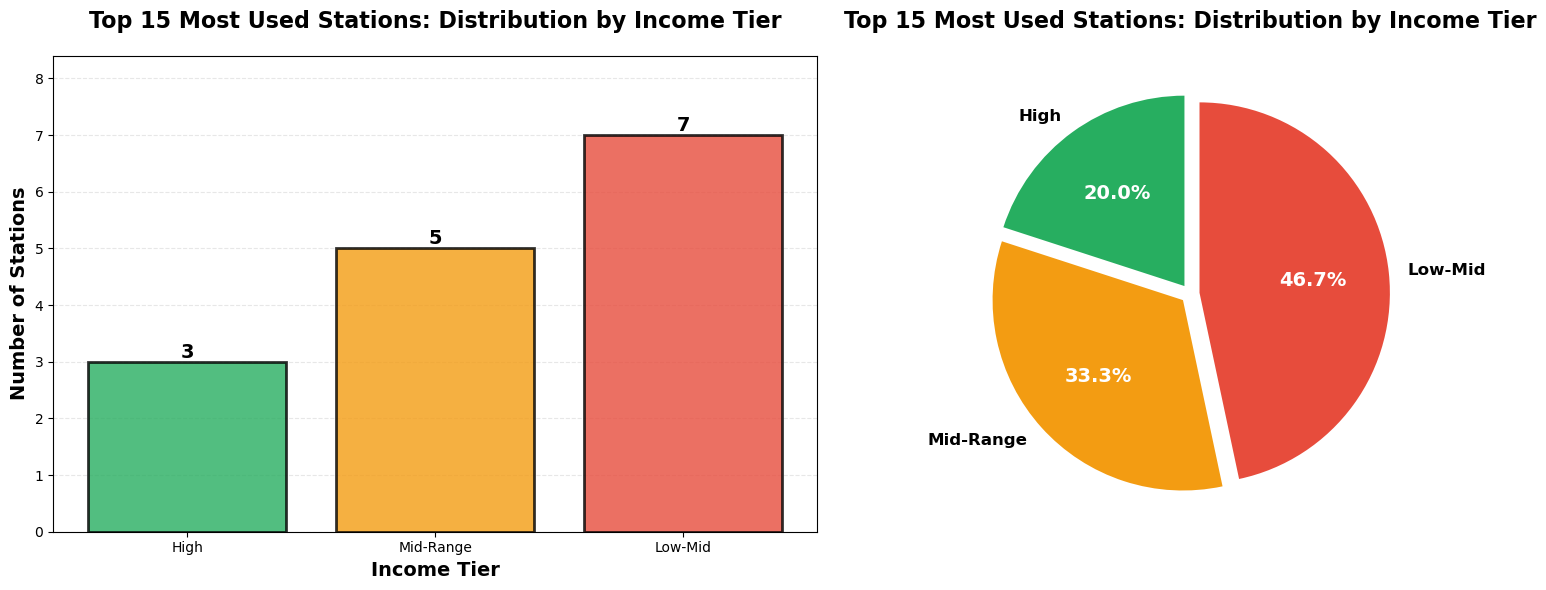


SUMMARY: Top 15 Stations Grouped by Income Tier

Total stations in top 15: 15

Breakdown by Income Tier:
  High        :  3 stations ( 20.0%) - 5,394 total sessions
  Mid-Range   :  5 stations ( 33.3%) - 9,027 total sessions
  Low-Mid     :  7 stations ( 46.7%) - 12,750 total sessions

Top 15 Station IDs by Income Tier:
  High        : 55, 119, 157
  Mid-Range   : 36, 68, 92, 98, 122
  Low-Mid     : 18, 27, 61, 124, 136, 150, 163


In [5]:
# Top 15 Most Used Charging Stations Grouped by Income Tier

# Import necessary libraries (if not already imported)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Load data if not already loaded
if 'se' not in globals():
    enriched_path = "../dataset/sessions_enriched.csv"
    se = pd.read_csv(enriched_path, parse_dates=["session_start_time"])
    print(f"Loaded data: {se.shape[0]:,} sessions")

# Count sessions per station
station_usage = se.groupby('station_id').size().reset_index(name='session_count')

# Get station details (income tier, district, etc.) - use first occurrence since all rows for same station have same info
station_details = se[['station_id', 'station_income_tier', 'district_name', 'operator_name']].drop_duplicates('station_id')

# Merge usage with station details and get top 15
top_stations = (station_usage
                .merge(station_details, on='station_id', how='left')
                .sort_values('session_count', ascending=False)
                .head(15))

# Normalize income tier names (handle variations)
def normalize_tier(tier):
    if pd.isna(tier):
        return 'Unknown'
    tier_str = str(tier).strip()
    if 'High' in tier_str or tier_str == 'high':
        return 'High'
    elif 'Mid-Range' in tier_str or 'Mid' in tier_str or tier_str == 'mid':
        return 'Mid-Range'
    elif 'Low' in tier_str or tier_str == 'low':
        return 'Low-Mid'
    return tier_str

top_stations['income_tier_normalized'] = top_stations['station_income_tier'].apply(normalize_tier)

# Group the top 15 stations by income tier
tier_counts = top_stations['income_tier_normalized'].value_counts().reindex(['High', 'Mid-Range', 'Low-Mid'], fill_value=0)

# Create color mapping for income tiers
income_tier_colors = {
    'High': '#27ae60',       # Green
    'Mid-Range': '#f39c12',  # Orange
    'Low-Mid': '#e74c3c'     # Red
}

# Create the visualization - Bar chart showing count per tier
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = ax1.bar(tier_counts.index, tier_counts.values, 
                color=[income_tier_colors.get(tier, '#95a5a6') for tier in tier_counts.index],
                edgecolor='black', linewidth=2, alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=14, fontweight='bold')

ax1.set_ylabel('Number of Stations', fontsize=14, fontweight='bold')
ax1.set_xlabel('Income Tier', fontsize=14, fontweight='bold')
ax1.set_title('Top 15 Most Used Stations: Distribution by Income Tier', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylim(0, max(tier_counts.values) * 1.2)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Pie chart
colors_pie = [income_tier_colors.get(tier, '#95a5a6') for tier in tier_counts.index]
wedges, texts, autotexts = ax2.pie(tier_counts.values, 
                                    labels=tier_counts.index,
                                    colors=colors_pie,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 12, 'fontweight': 'bold'},
                                    explode=[0.05, 0.05, 0.05])

# Make percentage text larger
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

ax2.set_title('Top 15 Most Used Stations: Distribution by Income Tier', 
              fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

# Save figure if savefig function exists, otherwise use plt.savefig
if 'savefig' in globals():
    savefig('top_15_stations_grouped_by_income_tier.png')
else:
    import os
    FIGS_DIR = "figs"
    os.makedirs(FIGS_DIR, exist_ok=True)
    plt.savefig(os.path.join(FIGS_DIR, 'top_15_stations_grouped_by_income_tier.png'), 
                dpi=150, bbox_inches='tight')

plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY: Top 15 Stations Grouped by Income Tier")
print("="*60)
print(f"\nTotal stations in top 15: {len(top_stations)}")
print(f"\nBreakdown by Income Tier:")
for tier in ['High', 'Mid-Range', 'Low-Mid']:
    count = tier_counts[tier] if tier in tier_counts.index else 0
    percentage = (count / len(top_stations)) * 100 if len(top_stations) > 0 else 0
    stations_in_tier = top_stations[top_stations['income_tier_normalized'] == tier]
    total_sessions = stations_in_tier['session_count'].sum() if len(stations_in_tier) > 0 else 0
    print(f"  {tier:12s}: {count:2d} stations ({percentage:5.1f}%) - {total_sessions:,} total sessions")

print(f"\nTop 15 Station IDs by Income Tier:")
for tier in ['High', 'Mid-Range', 'Low-Mid']:
    stations_in_tier = top_stations[top_stations['income_tier_normalized'] == tier]
    if len(stations_in_tier) > 0:
        station_ids = sorted(stations_in_tier['station_id'].tolist())
        print(f"  {tier:12s}: {', '.join(map(str, station_ids))}")
